### Importing Data Set

In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv('MNIST.csv')

df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Checking is there any null values

In [3]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

### Checking Datatype

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


### Train Test Split

In [7]:
from sklearn.model_selection import train_test_split

X=df.drop('label', axis=1)
Y=df['label']

X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, random_state=42)

### Standardiztion

In [8]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)

### PCA

In [25]:
from sklearn.decomposition import PCA

pca=PCA(n_components=3)

X_train_pca=pca.fit_transform(X_train_scale )
X_test_pca=pca.transform(X_test_scale)

### EigenValues

In [26]:
print(pca.explained_variance_ratio_)

[0.05785192 0.0414927  0.03804239]


### EigenAttributes

In [27]:
print(pca.components_)

[[ 0.  0.  0. ...  0.  0.  0.]
 [-0. -0. -0. ... -0. -0. -0.]
 [ 0.  0.  0. ...  0.  0.  0.]]


### Finding Shape of Final Data Set

In [28]:
X_train_pca.shape

(33600, 3)

### Plotting

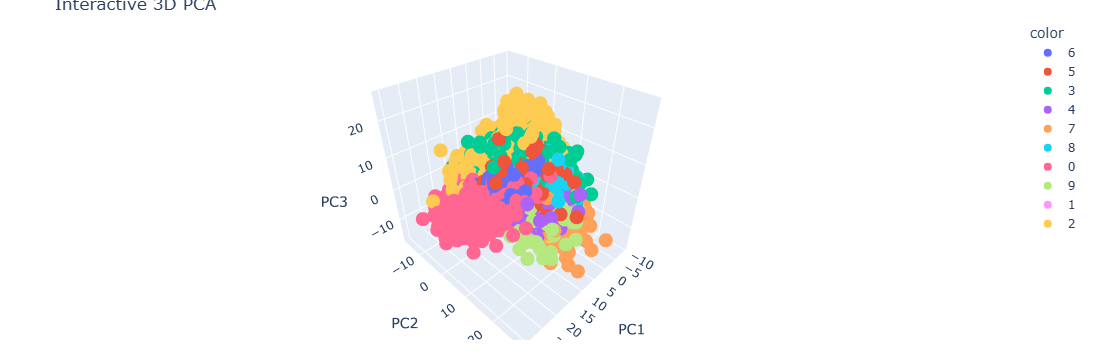

In [32]:
import plotly.express as px

# 1. Convert targets to strings so colors are distinct categories
y_train_str = Y_train.astype(str)

# 2. Create the 3D scatter plot
fig = px.scatter_3d(
    x=X_train_pca[:, 0], 
    y=X_train_pca[:, 1], 
    z=X_train_pca[:, 2],
    color=y_train_str,
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
    title='Interactive 3D PCA'
)

# 3. Clean up the layout (optional)
fig.update_layout(margin=dict(l=20, r=20, t=20, b=20))

# 4. Show the interactive plot
fig.show()

In [33]:
# Instead of a whole number, pass a decimal between 0 and 1
pca_95 = PCA(n_components=0.95)

# Fit and transform your scaled data
X_train_95 = pca_95.fit_transform(X_train_scale)

# Now check how many components it chose
print("Components needed for 95% variance:", pca_95.n_components_)

Components needed for 95% variance: 315
